# Using ANAI on the Mobile Price Classification Dataset

#### Recently I came across an automated machine learning library on github called [ANAI](http://github.com/Revca-ANAI/ANAI). As per the github repo, ANAI is an Automated Machine Learning Python Library that works on tabular data intended to save time when performing data analysis. 

#### ANAI assists you with everything right from the beginning i.e Ingesting data using the inbuilt connectors, preprocessing, feature engineering, model building, model evaluation, model tuning and generating explanations on the model results with Explainable AI.

# Installing ANAI

In [1]:
!pip install anai-opensource

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 548.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.1/242.1 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 182.1/182.1 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.7/278.7 kB 7.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 761.5/761.5 kB 8.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.1/269.1 kB 16.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 15.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.3/21.3 MB 26.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 9.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... - done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.6/93.6 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━

# Importing ANAI

In [2]:
import anai
from anai.preprocessing import Preprocessor

# Loading the data set with ANAI
#### I'm using the Mobile Price Data set which combines all the features of mobile phones.

In [3]:
df = anai.load(df_filepath = '../input/mobile-price-classification/train.csv')

Loading Data [*]

Data Loaded Successfully [ ✓ ]



In [4]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
df.info()

<class 'modin.pandas.dataframe.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  -------------  --------------  -----  
 0   battery_power  2000 non-null   int64
 1   blue           2000 non-null   int64
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64
 4   fc             2000 non-null   int64
 5   four_g         2000 non-null   int64
 6   int_memory     2000 non-null   int64
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64
 9   n_cores        2000 non-null   int64
 10  pc             2000 non-null   int64
 11  px_height      2000 non-null   int64
 12  px_width       2000 non-null   int64
 13  ram            2000 non-null   int64
 14  sc_h           2000 non-null   int64
 15  sc_w           2000 non-null   int64
 16  talk_time      2000 non-null   int64
 17  three_g        2000 non-null   int64
 18  touch_screen   2000 non-null   int6

# Running the Preprocessor pipeline on the data set 
#### With `Preprocessor()` we can start looking at the data discrepancies within the data and see all the statistics such as missing values, duplicacy, outliers to get the data quality.

In [6]:
prep = Preprocessor(dataset=df, target='price_range')

summary = prep.summary()
summary.head(10)

,Stats
No. of Cells,42000
No. of Variables,21
No. of Records,2000
Missing Cells,0.0 %
Missing Cells Count,0
Duplicacy,0.00 %
Duplicate Cell Count,0
Anomaly Count,100


#### We can also get a column summary for all the columns.

In [7]:
column_summary = prep.column_summary()
column_summary.head(24)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
Type,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,...,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric,Numeric
Missing Value %,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Mean,1238.52,0.49,1.52,0.51,4.31,0.52,32.05,0.50,140.25,4.52,...,645.11,1251.52,2124.21,12.31,5.77,11.01,0.76,0.50,0.51,1.50
Mode,618.00,0.00,0.50,1.00,0.00,1.00,27.00,0.10,182.00,4.00,...,347.00,874.00,1229.00,17.00,1.00,7.00,1.00,1.00,1.00,0.00
Maximum value,1998.00,1.00,3.00,1.00,19.00,1.00,64.00,1.00,200.00,8.00,...,1960.00,1998.00,3998.00,19.00,18.00,20.00,1.00,1.00,1.00,3.00
Median,1226.00,0.00,1.50,1.00,3.00,1.00,32.00,0.50,141.00,4.00,...,564.00,1247.00,2146.50,12.00,5.00,11.00,1.00,1.00,1.00,1.50
Minimum value,501.00,0.00,0.50,0.00,0.00,0.00,2.00,0.10,80.00,1.00,...,0.00,500.00,256.00,5.00,0.00,2.00,0.00,0.00,0.00,0.00
Standard Deviation,439.42,0.50,0.82,0.50,4.34,0.50,18.15,0.29,35.40,2.29,...,443.78,432.20,1084.73,4.21,4.36,5.46,0.43,0.50,0.50,1.12
99% Quartile,1987.00,1.00,3.00,1.00,16.00,1.00,64.00,1.00,199.00,8.00,...,1791.01,1987.00,3958.01,19.00,17.00,20.00,1.00,1.00,1.00,3.00
90% Quartile,1851.00,1.00,2.70,1.00,11.00,1.00,57.00,0.90,189.00,8.00,...,1285.00,1854.00,3637.70,18.00,12.00,19.00,1.00,1.00,1.00,3.00


#### There are multiple things within the ANAI package such as imputing missing values too. Unfortunately, I could not use it here because of a clean data set.
```python
df1 = prep.impute(method = 'mean')
```

In [8]:
df.isna().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

# Splitting the data

In [9]:
features, labels = prep.encode(split = True)

In [10]:
features.head(4)

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,6,905,1988,2631,17,3,7,1,1,0
2,563,1,0.5,1,2,1,41,0.9,145,5,6,1263,1716,2603,11,2,9,1,1,0
3,615,1,2.5,0,0,0,10,0.8,131,6,9,1216,1786,2769,16,8,11,1,0,0


In [11]:
X_train, X_val, y_train, y_val, scaler = prep.prepare(features, labels, test_size = 0.2, random_state = 42, smote = False, k_neighbors = 3)


In [12]:
X_train.shape, X_val.shape, y_val.shape, y_train.shape

((1600, 20), (400, 20), (400,), (1600,))

# Model Training
#### So, interestingly enough, the above steps were not required for training models with ANAI. We can use the below statement and run `anai.run()` by passing in the dataset (or the filepath), the target value and the predictors, with additional extra params too. But the above methods become convenient during data analysis.<br>
#### ANAI automatically selects the type of task (regression or classification) that we have to perform based on the target value but we can also pass it manually with the param `task`.
#### Here, we are passing in predictors as Random Forest, CatBoost, XGBoost and LightGBM (check out the [documentation](https://github.com/Revca-ANAI/ANAI to see the number of models they are offering). The data will be passed to all of them for training and ANAI will give us the best model after the training stops.

## Hyper Parameter Tuning
#### For hyperparameter tuning, ANAI uses Optuna to tune hyperparameters automatically after just passing `tune=True` in `anai.run()`.

In [13]:
models = anai.run(filepath='../input/mobile-price-classification/train.csv', target='price_range', predictor=['rfc', 'cat', 'xgb', 'lgbm'], cv_folds=5)

Task: Classification 


░█████╗░███╗░░██╗░█████╗░██╗
██╔══██╗████╗░██║██╔══██╗██║
███████║██╔██╗██║███████║██║
██╔══██║██║╚████║██╔══██║██║
██║░░██║██║░╚███║██║░░██║██║
╚═╝░░╚═╝╚═╝░░╚══╝╚═╝░░╚═╝╚═╝
 

Started ANAI [ ✓ ]

Preprocessing Started [*]

Preprocessing Done [ ✓ ]

Training ANAI [*]

Ensembling on top 4 models

Traceback (most recent call last):
  File "/opt/conda/lib/python3.7/site-packages/anai/supervised/__init__.py", line 546, in __fitall
    self.X_train, self.y_train, self.X_val, self.y_val, cv_folds=self.cv_folds, estimators=estimators, est=est1)
  File "/opt/conda/lib/python3.7/site-packages/anai/utils/ensembler.py", line 86, in ensemble
    self.model = self.__ensembling_models[model_name]()
  File "/opt/conda/lib/python3.7/site-packages/anai/utils/ensembler.py", line 145, in _stacking_ensembler_cv
    stacking_model.fit(self.X_train, self.y_train)
  File "/opt/conda/lib/python3.7/site-packages/mlxtend/classifier/stacking_cv_classification.py", line 284, in fit
    met

,Name,Accuracy,Cross Validated Accuracy
0,CatBoost Classifier,94.25,93.3125
1,XGBoost Classifier,90.25,90.0625
2,LightGBM Classifier,90.75,89.6875
3,Random Forest Classifier,86.75,87.3125



Completed ANAI Run [ ✓ ]

Saved Best Model at ('anai_info/best/classifier/models/CatBoost_Classifier_1661614209.pkl', 'anai_info/best/classifier/scalers/CatBoost_Classifier_Scaler_1661614209.pkl')  

Time Elapsed :  102.91 seconds 



# Explaining the Results
#### They have included some of the explanatory methods too in ANAI which help us explain our model functioning that happens internally. It shows us how the features are affecting the predictions from a model.

#### The first one is the **Permutation Feature Importance** method, which randomly shuffles (permutes) a feature value and sees how the model accuracy or errors changes. Based on this it gives that feature an importance score looking at how much increase or reduction was there in the performance.

#### The explanation is for the top performing model, CatBoost in this case.

In [14]:
models.explain('perm')

Explaining Best ANAI model [*]



Explaining ANAI Done [ ✓ ]



#### The other method that is available is the commonly known Explainable AI method called **SHAP**. SHAP calculates the contribution made by all of the features to make a prediction. 
#### With ANAI we are able to generate all sorts of SHAP charts such as the summary plots, beeswarm plots, and also SHAP plots for each feature.

Explaining Best ANAI model [*]



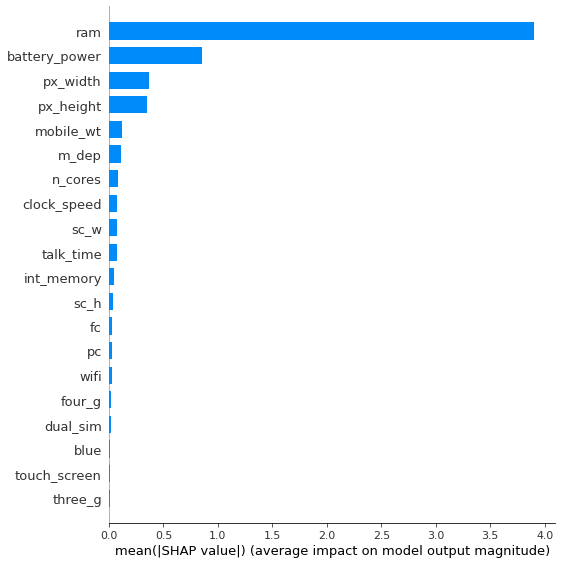

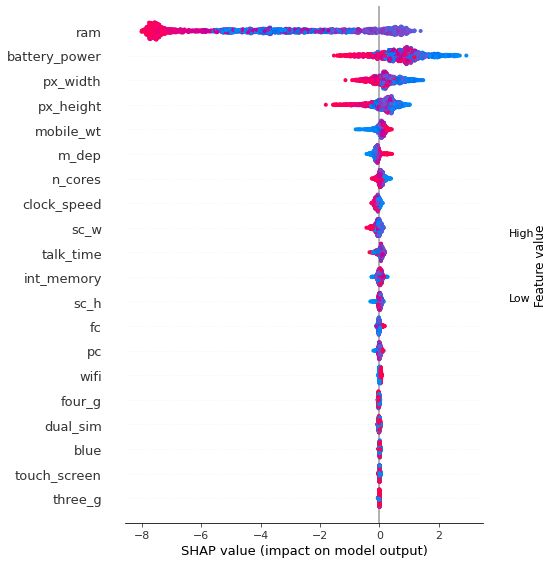

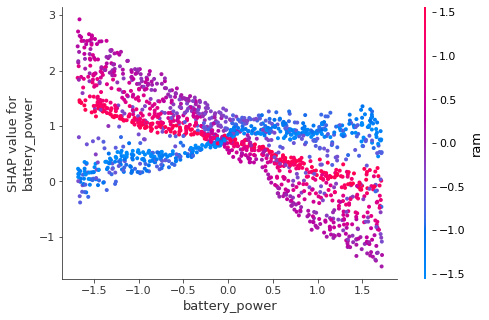

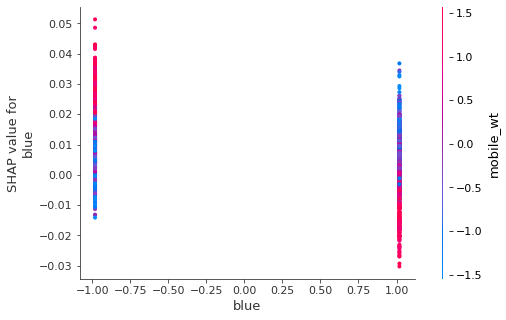

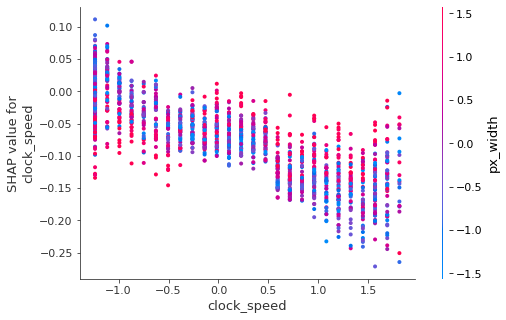

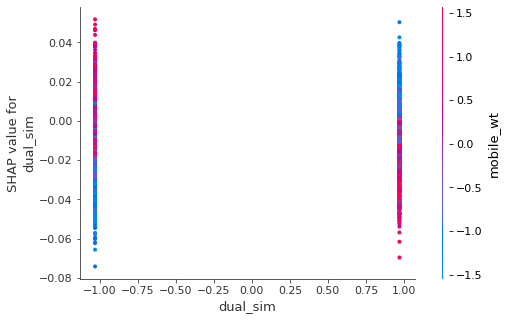

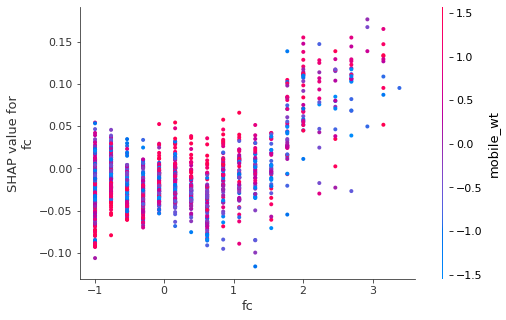

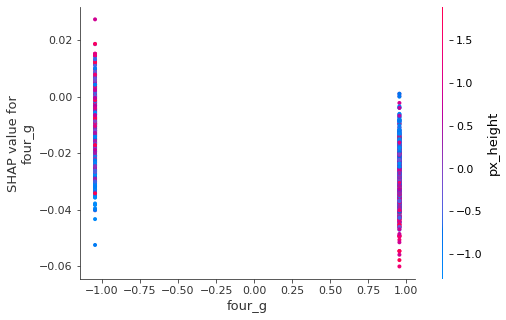

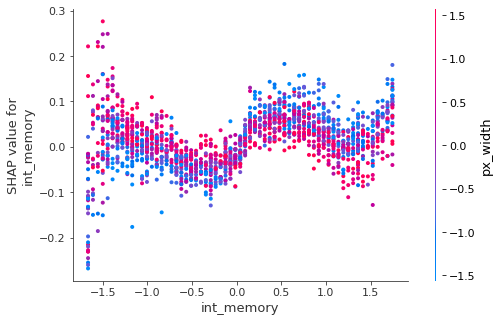

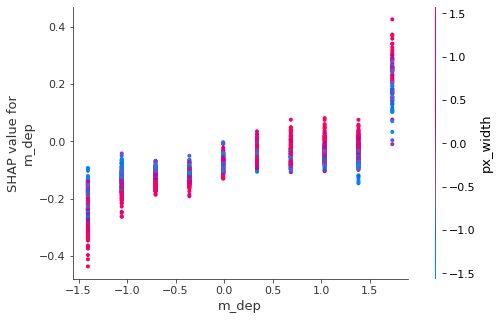

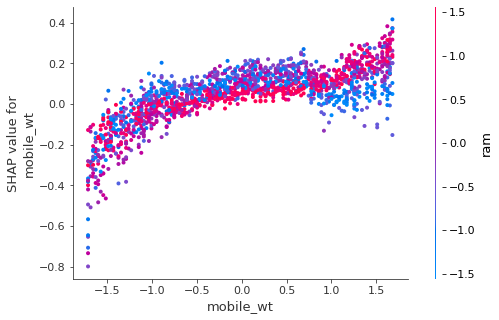

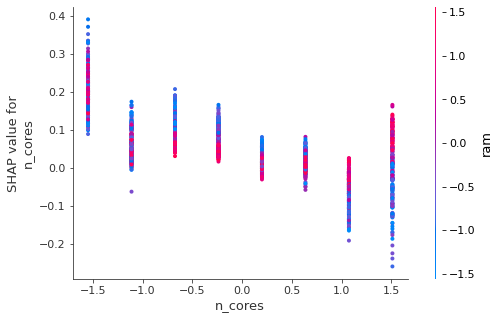

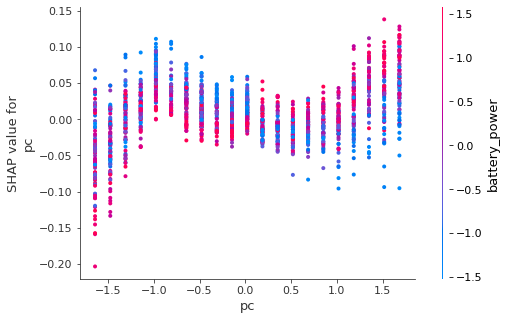

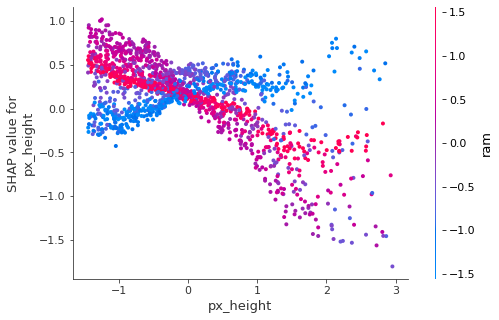

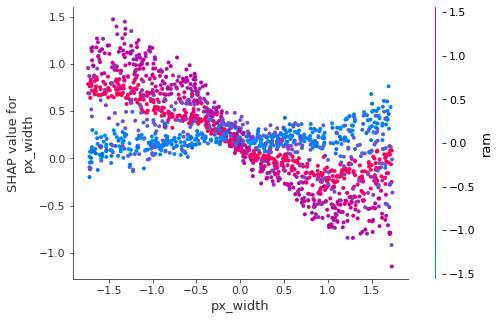

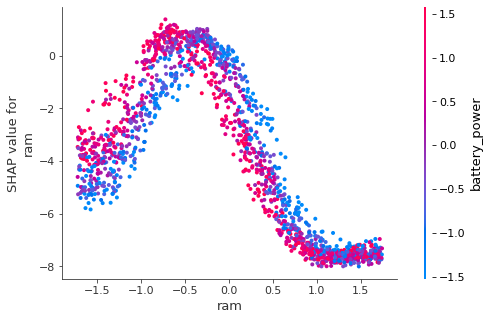

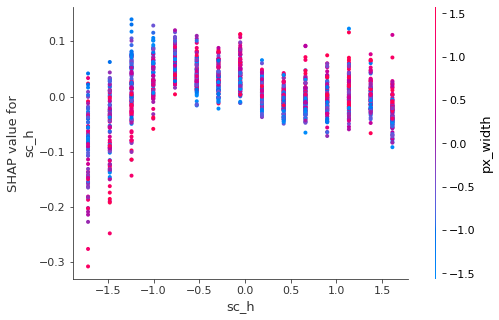

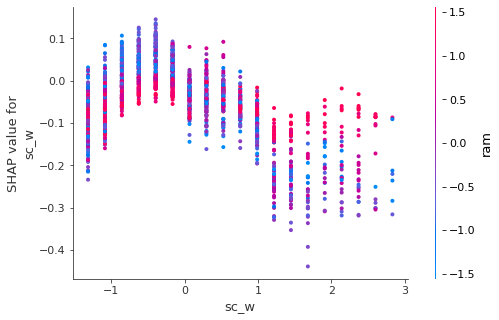

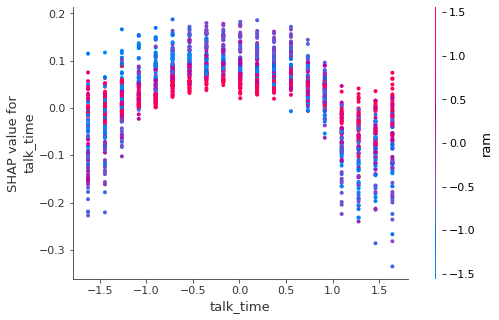

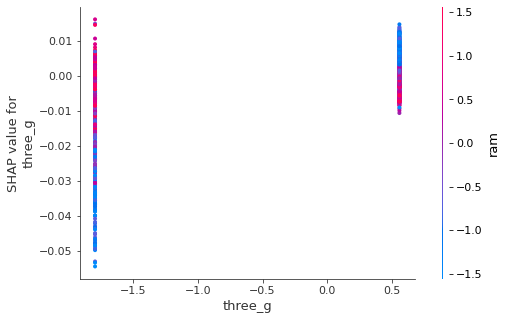

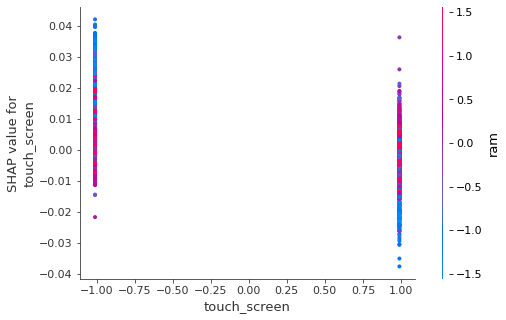

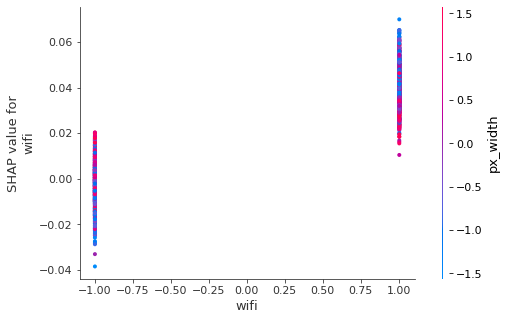

Explaining ANAI Done [ ✓ ]



In [15]:
models.explain('shap')

# Final Results

In [16]:
models.result()

,Name,Accuracy,Cross Validated Accuracy,Model
0,CatBoost Classifier,94.25,93.3125,<catboost.core.CatBoostClassifier object at 0x...
1,XGBoost Classifier,90.25,90.0625,"XGBClassifier(base_score=0.5, booster='gbtree'..."
2,LightGBM Classifier,90.75,89.6875,LGBMClassifier()
3,Random Forest Classifier,86.75,87.3125,"(DecisionTreeClassifier(max_features='auto', r..."


# Saving the models
#### To save the models we just have to say `anai.save([<path-to-model.pkl>, <path-to-scaler.pkl>])`.

# Conclusion
### So, we can conclude that ANAI being an open source library offers a lot of Machine Learning features and completely automates how we build our models.
### Try it out yourself if you found it interesting.

### 🙏🏼Thanks for reading till the end and do upvote if this was worth your time!

# References
1. [ANAI Trial Notebook](https://www.kaggle.com/code/d4rklucif3r/introducing-anai-stroke-prediction/notebook)
2. [ANAI Github repo](https://github.com/Revca-ANAI/ANAI)